In [1]:
import zipfile
import os

zip_path = '/content/Car_Price_Prediction.zip'
extract_path = '/content/car_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['car data.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('/content/car_data/car data.csv')

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (301, 9)


In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
print(df.columns.tolist())

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [9]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows: 2
Dataset shape after removing duplicates: (299, 9)


In [10]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [11]:
df['Car_Age'] = 2026 - df['Year']

print("Car_Age feature created successfully!")
df[['Year', 'Car_Age']].head()

Car_Age feature created successfully!


,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [12]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [13]:
print("Fuel Types:")
print(df['Fuel_Type'].unique())

print("\nSelling Types:")
print(df['Selling_type'].unique())

print("\nTransmission Types:")
print(df['Transmission'].unique())

print("\nOwner Types:")
print(df['Owner'].unique())

Fuel Types:
['Petrol' 'Diesel' 'CNG']

Selling Types:
['Dealer' 'Individual']

Transmission Types:
['Manual' 'Automatic']

Owner Types:
[0 1 3]


In [14]:
print(df['Fuel_Type'].value_counts())

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64


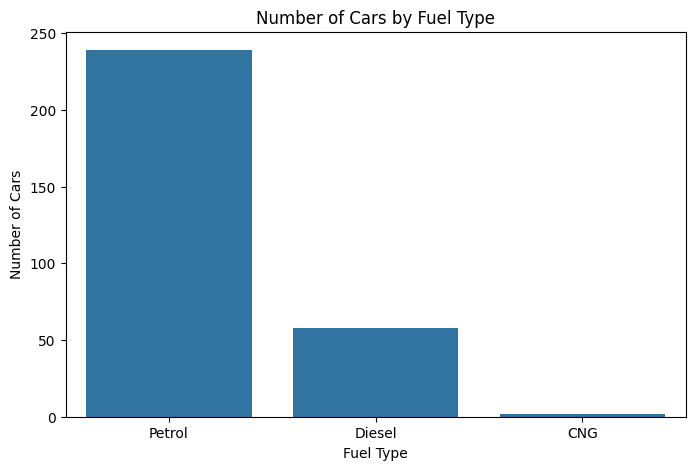

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Fuel_Type')

plt.title('Number of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.show()

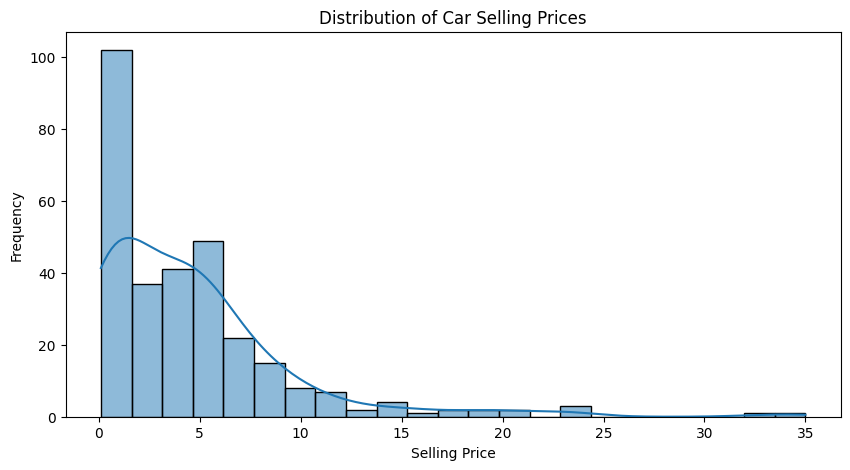

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Selling_Price'], kde=True)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')

plt.show()

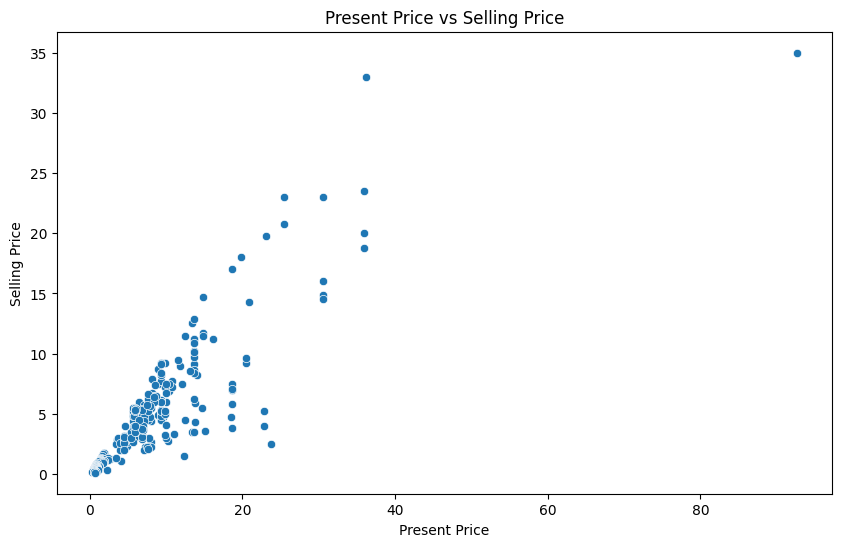

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Present_Price',
    y='Selling_Price'
)

plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')

plt.show()

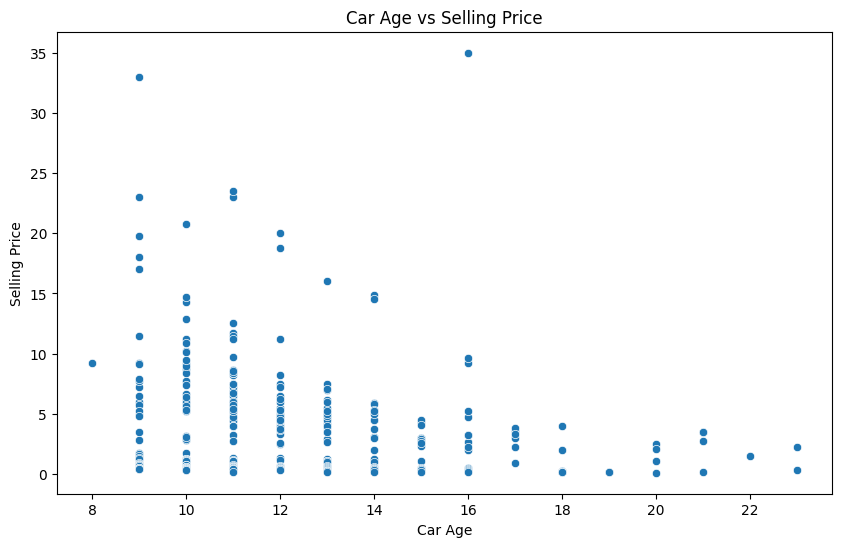

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Car_Age',
    y='Selling_Price'
)

plt.title('Car Age vs Selling Price')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')

plt.show()

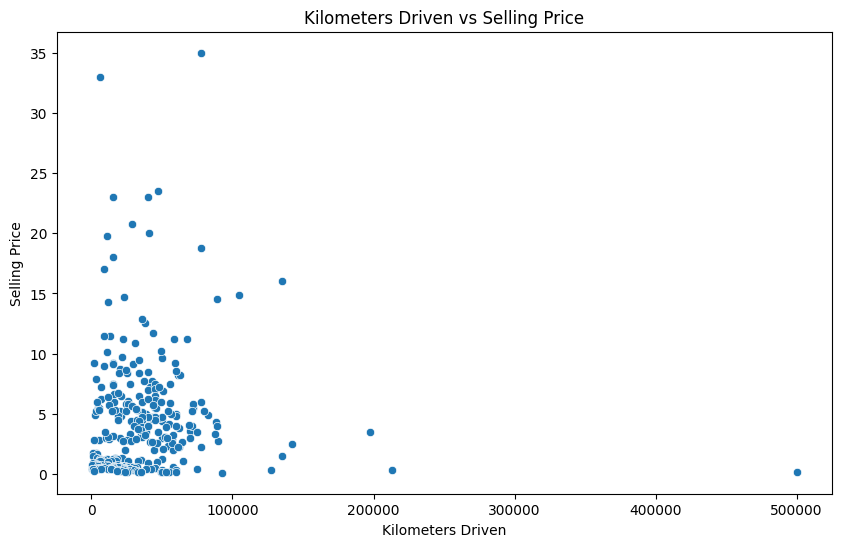

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Driven_kms',
    y='Selling_Price'
)

plt.title('Kilometers Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')

plt.show()

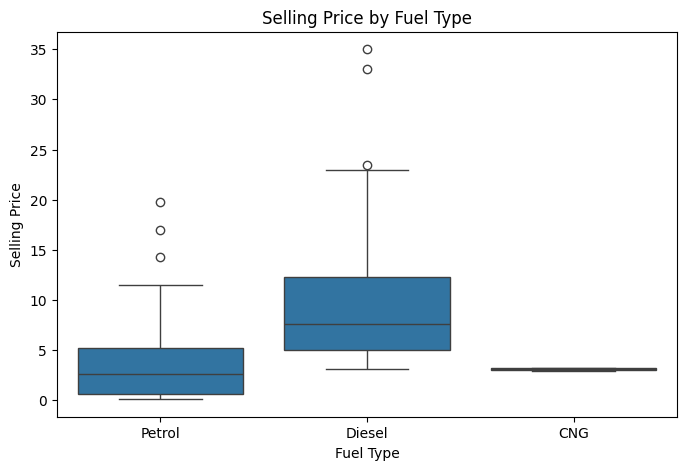

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Fuel_Type',
    y='Selling_Price'
)

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

plt.show()

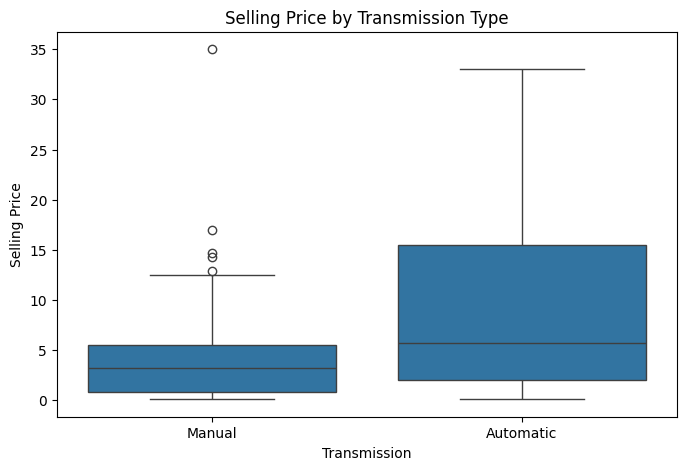

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Transmission',
    y='Selling_Price'
)

plt.title('Selling Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Selling Price')

plt.show()

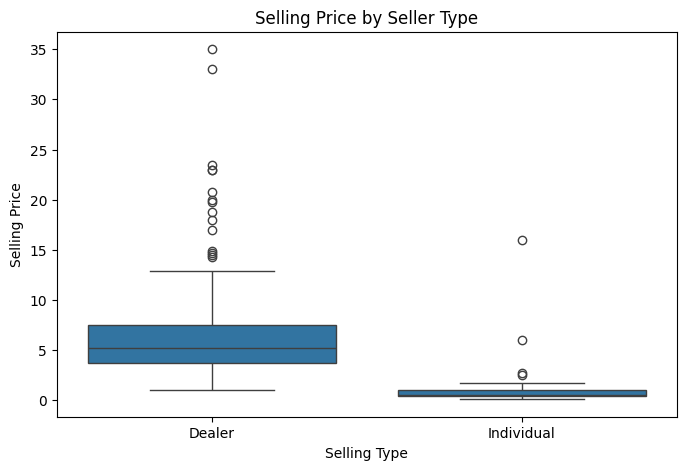

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Selling_type',
    y='Selling_Price'
)

plt.title('Selling Price by Seller Type')
plt.xlabel('Selling Type')
plt.ylabel('Selling Price')

plt.show()

Fuel_Type
Diesel    10.102759
Petrol     3.264184
CNG        3.100000
Name: Selling_Price, dtype: float64


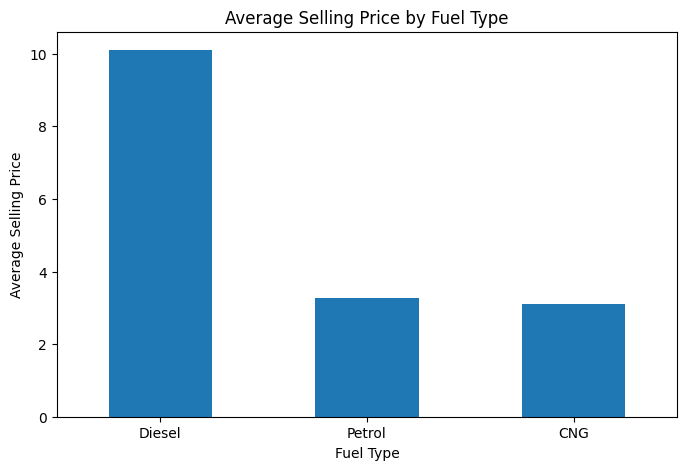

In [23]:
fuel_price = df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)

print(fuel_price)
plt.figure(figsize=(8, 5))

fuel_price.plot(kind='bar')

plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price')

plt.xticks(rotation=0)
plt.show()

Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


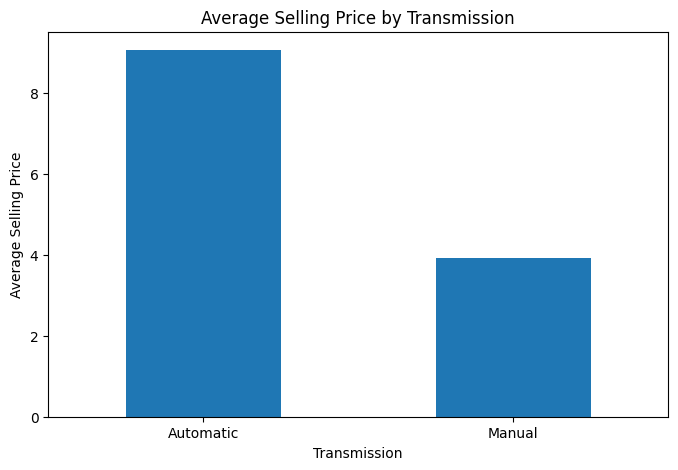

In [24]:
transmission_price = df.groupby('Transmission')['Selling_Price'].mean().sort_values(ascending=False)
print(transmission_price)
plt.figure(figsize=(8, 5))

transmission_price.plot(kind='bar')

plt.title('Average Selling Price by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price')

plt.xticks(rotation=0)
plt.show()

In [25]:
numeric_df = df[
    [
        'Year',
        'Selling_Price',
        'Present_Price',
        'Driven_kms',
        'Owner',
        'Car_Age'
    ]
]

correlation = numeric_df.corr()

print(correlation)

                   Year  Selling_Price  Present_Price  Driven_kms     Owner  \
Year           1.000000       0.234369      -0.053167   -0.525714 -0.181639   
Selling_Price  0.234369       1.000000       0.876305    0.028566 -0.087880   
Present_Price -0.053167       0.876305       1.000000    0.205224  0.009948   
Driven_kms    -0.525714       0.028566       0.205224    1.000000  0.089367   
Owner         -0.181639      -0.087880       0.009948    0.089367  1.000000   
Car_Age       -1.000000      -0.234369       0.053167    0.525714  0.181639   

                Car_Age  
Year          -1.000000  
Selling_Price -0.234369  
Present_Price  0.053167  
Driven_kms     0.525714  
Owner          0.181639  
Car_Age        1.000000  


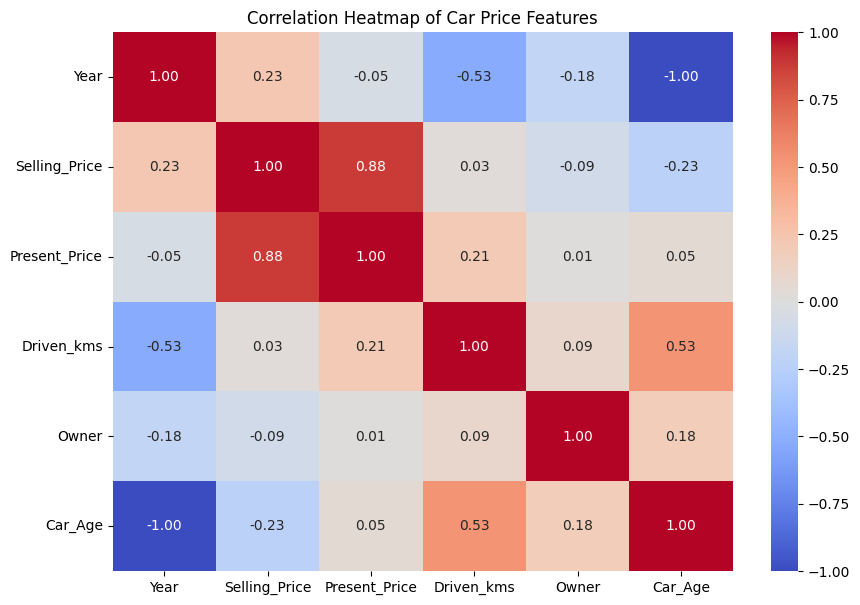

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Car Price Features')

plt.show()

Age_Group
0-3 Years          NaN
4-6 Years          NaN
7-10 Years    5.640941
10+ Years     4.172056
Name: Selling_Price, dtype: float64


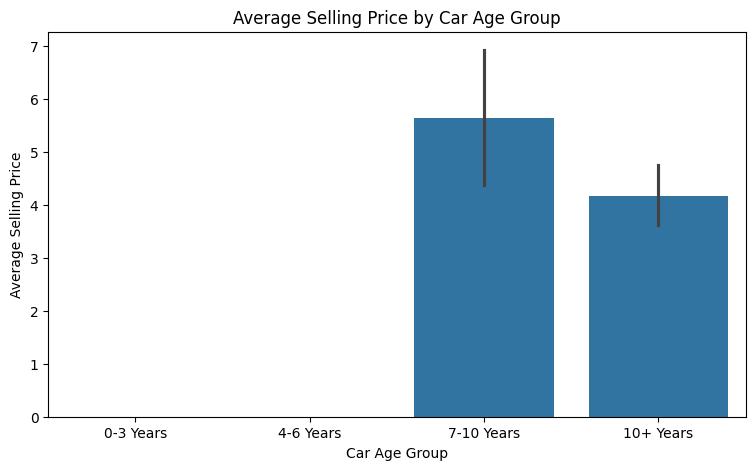

In [28]:
df['Age_Group'] = pd.cut(
    df['Car_Age'],
    bins=[0, 3, 6, 10, 50],
    labels=['0-3 Years', '4-6 Years', '7-10 Years', '10+ Years']
)

print(df.groupby('Age_Group', observed=False)['Selling_Price'].mean())
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x='Age_Group',
    y='Selling_Price'
)

plt.title('Average Selling Price by Car Age Group')
plt.xlabel('Car Age Group')
plt.ylabel('Average Selling Price')

plt.show()

In [29]:
top_cars = df.nlargest(10, 'Selling_Price')

print(
    top_cars[
        ['Car_Name', 'Year', 'Present_Price', 'Selling_Price']
    ]
)

        Car_Name  Year  Present_Price  Selling_Price
85  land cruiser  2010          92.60          35.00
63      fortuner  2017          36.23          33.00
62      fortuner  2015          35.96          23.50
50      fortuner  2015          30.61          23.00
81        innova  2017          25.39          23.00
94        innova  2016          25.39          20.75
58      fortuner  2014          35.96          19.99
65        innova  2017          23.15          19.75
61      fortuner  2014          35.96          18.75
51        innova  2017          19.77          18.00


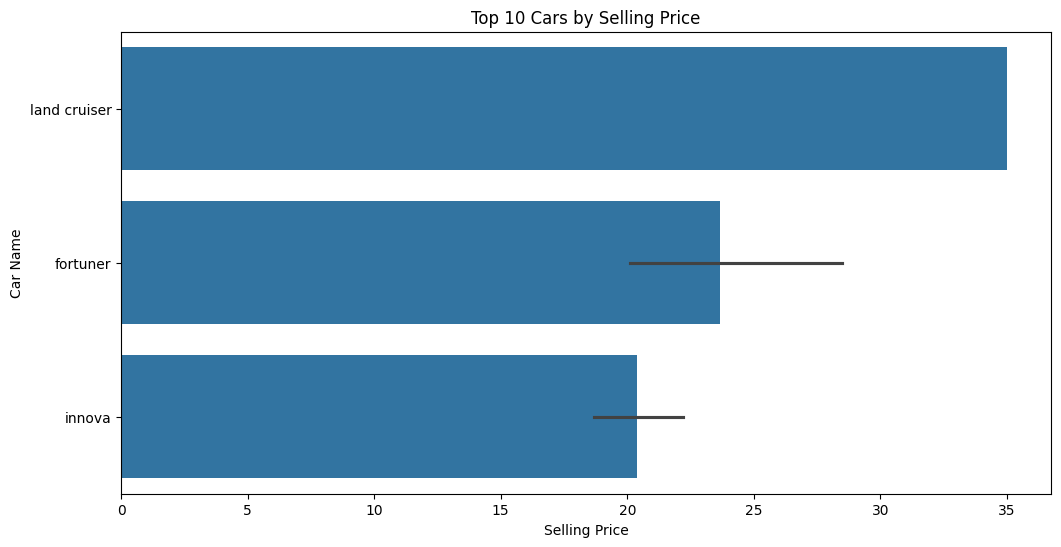

In [30]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_cars,
    x='Selling_Price',
    y='Car_Name'
)

plt.title('Top 10 Cars by Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Car Name')

plt.show()

In [31]:
features = [
    'Year',
    'Present_Price',
    'Driven_kms',
    'Fuel_Type',
    'Selling_type',
    'Transmission',
    'Owner',
    'Car_Age'
]

X = df[features]
y = df['Selling_Price']

print("Features selected successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features selected successfully!
X shape: (299, 8)
y shape: (299,)


In [32]:
categorical_features = [
    'Fuel_Type',
    'Selling_type',
    'Transmission'
]

numerical_features = [
    'Year',
    'Present_Price',
    'Driven_kms',
    'Owner',
    'Car_Age'
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Fuel_Type', 'Selling_type', 'Transmission']
Numerical features: ['Year', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age']


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 8)
Testing data: (60, 8)


In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [36]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [37]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [38]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[ 9.50615  8.27     0.4385   6.9195  18.80325  5.2965   6.75025  1.1905
  7.85075  0.3152 ]


In [39]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Performance
-----------------
Mean Absolute Error (MAE): 1.5729524999999995
Root Mean Squared Error (RMSE): 3.8363884588405552
R² Score: 0.4289478654186445


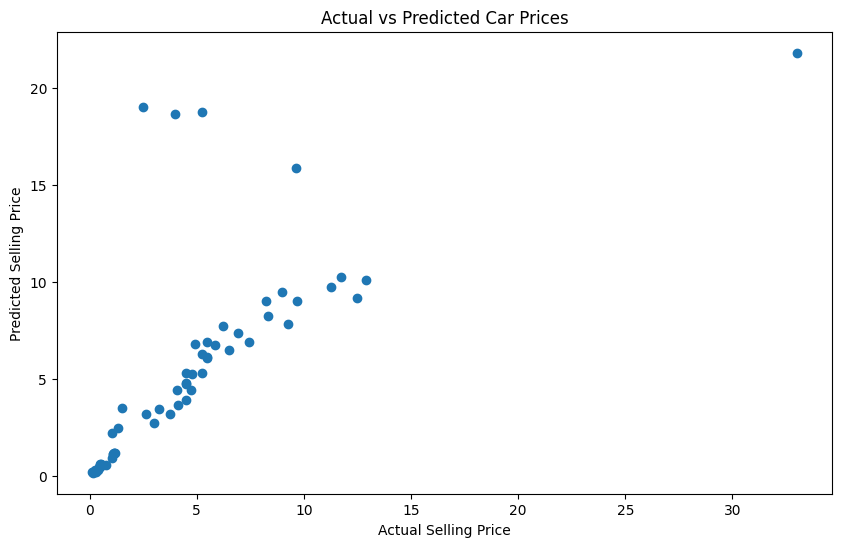

In [40]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Prices')

plt.show()

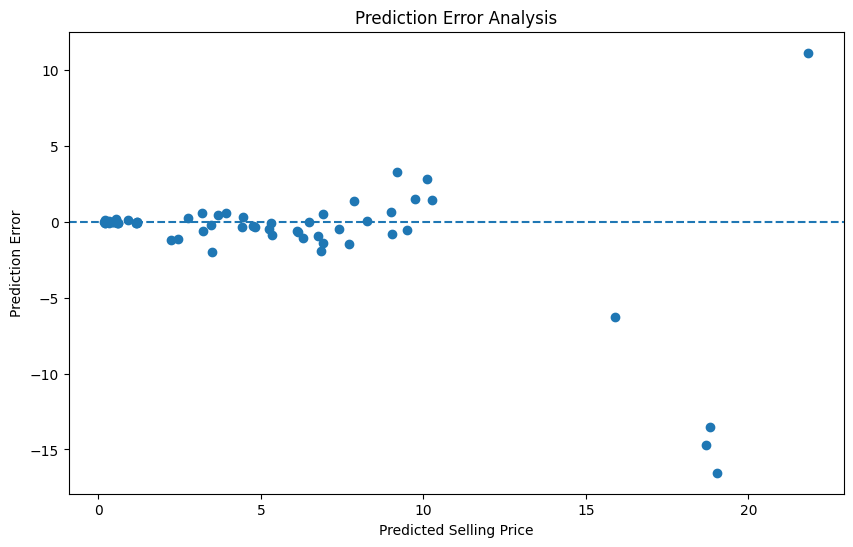

In [41]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Selling Price')
plt.ylabel('Prediction Error')
plt.title('Prediction Error Analysis')

plt.show()

In [42]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

results['Absolute Error'] = abs(
    results['Actual Price'] - results['Predicted Price']
)

results.head(10)

,Actual Price,Predicted Price,Absolute Error
0,8.99,9.50615,0.51615
1,8.35,8.27000,0.08000
2,0.45,0.43850,0.01150
3,7.45,6.91950,0.53050
4,5.25,18.80325,13.55325
5,5.25,5.29650,0.04650
6,5.85,6.75025,0.90025
7,1.15,1.19050,0.04050
8,9.25,7.85075,1.39925
9,0.38,0.31520,0.06480


In [43]:
print("===== CAR PRICE PREDICTION MODEL PERFORMANCE =====")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

===== CAR PRICE PREDICTION MODEL PERFORMANCE =====
Mean Absolute Error (MAE): 1.5730
Root Mean Squared Error (RMSE): 3.8364
R² Score: 0.4289


In [44]:
performance = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Value': [mae, rmse, r2]
})

performance

,Metric,Value
0,MAE,1.572952
1,RMSE,3.836388
2,R² Score,0.428948


# 🚗 Car Price Prediction with Machine Learning

### CodeAlpha Data Science Internship — Task 3

**Intern:** Vishwasree Sunkara  
**Organization:** CodeAlpha  
**Domain:** Data Science  
**Task:** Car Price Prediction with Machine Learning

---

## Project Overview

This project develops a machine learning model to predict car selling prices based on various features such as year, present price, kilometers driven, fuel type, seller type, transmission, and previous ownership.

The project includes data preprocessing, exploratory data analysis, feature engineering, visualization, machine learning model development, prediction, and model evaluation.

## Problem Statement

Determining the appropriate selling price of a used car can be difficult because the price depends on several factors such as the car's age, present price, kilometers driven, fuel type, seller type, transmission, and ownership.

The objective of this project is to develop a machine learning model that can predict the selling price of a car using historical car data and relevant vehicle features.

## Objectives

- Analyze the car price dataset.
- Clean and preprocess the data.
- Perform exploratory data analysis.
- Study factors affecting car selling prices.
- Analyze relationships between car features and selling price.
- Create useful features through feature engineering.
- Convert categorical features into numerical form.
- Build a machine learning regression model.
- Predict car selling prices.
- Evaluate model performance using MAE, RMSE, and R² Score.
- Visualize actual and predicted prices.

## Dataset Description

The dataset contains information about used cars and their selling prices.

### Important Features

- **Car_Name** — Name of the car.
- **Year** — Manufacturing year of the car.
- **Selling_Price** — Selling price of the car and the target variable.
- **Present_Price** — Current/present price of the car.
- **Driven_kms** — Number of kilometers driven.
- **Fuel_Type** — Fuel type of the car.
- **Selling_type** — Type of seller.
- **Transmission** — Transmission type.
- **Owner** — Number of previous owners.
- **Car_Age** — Derived feature representing the age of the car.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab
- Exploratory Data Analysis
- Data Visualization
- Feature Engineering
- Machine Learning

## Skills Demonstrated

- Python Programming
- Pandas
- NumPy
- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Feature Engineering
- Categorical Data Encoding
- Machine Learning
- Regression
- Random Forest
- Model Evaluation
- Data Interpretation